In [44]:
"""
MATBG / AA-BLG Continuum Model — Bistritzer-MacDonald
======================================================
Standalone functions (no class) matching TBGModel behaviour exactly.

Functions
---------
  solve_band_structure        — band structure along high-symmetry path
  solve_along_ky0             — dispersion along k_y = 0
  compute_fermi_velocities    — Fermi surface and Fermi velocity (TBG only)
  plot_flat_band_contours_MATBG
  plot_flat_band_contours_AABLG

Dependencies
------------
    numpy, scipy, matplotlib
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from matplotlib.ticker import StrMethodFormatter


# ---------------------------------------------------------------------------
# Rotation matrix
# ---------------------------------------------------------------------------

def rotation_matrix(theta):
    """Return 2D rotation matrix for angle theta (radians)."""
    return np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])


# ---------------------------------------------------------------------------
# Q-lattice builder (TBG only)
# ---------------------------------------------------------------------------

def _build_q_lattice(theta, a, cut):
    """
    Build the moiré reciprocal Q lattice for TBG.

    Parameters
    ----------
    theta : float   Twist angle (radians)
    a     : float   Graphene lattice constant (nm)
    cut   : int     Shell cutoff

    Returns
    -------
    q, b, Q, Q_nn
    NOTE: k_theta is NOT returned.
          Always compute externally as  4*pi/a * sin(theta/2).
    """
    kD = 4 * np.pi / (3 * a)
    k1 = np.array([kD, 0])
    k2 = np.array([np.cos(2 * np.pi / 3) * kD, np.sin(2 * np.pi / 3) * kD])
    k3 = -np.array([np.cos(np.pi / 3) * kD, np.sin(np.pi / 3) * kD])

    R = rotation_matrix
    q1 = R(theta / 2) @ k1 - R(-theta / 2) @ k1
    q2 = R(theta / 2) @ k2 - R(-theta / 2) @ k2
    q3 = R(theta / 2) @ k3 - R(-theta / 2) @ k3
    q  = np.array([q1, q2, q3])

    # k_theta used only for shell cutoff during Q-lattice construction
    k_theta_build = max(np.linalg.norm(q1), np.linalg.norm(q2), np.linalg.norm(q3))

    b1 = q2 - q3
    b2 = q1 - q3
    b  = np.array([b1, q1 - q3, q2 - q1])

    Q = []
    for i in range(-cut, cut + 1):
        for j in range(-cut, cut + 1):
            for layer in [0, 1]:
                qvec = i * b1 + j * b2 - layer * q1 - q3
                if np.linalg.norm(qvec) <= np.sqrt(3) * k_theta_build * cut:
                    Q.append([qvec[0], qvec[1], layer])
    Q  = np.array(Q)
    Nq = len(Q)

    Qxy  = np.round(Q[:, :2], 6).tolist()
    Q_nn = {}
    for i in range(Nq):
        Q_nn[i] = []
        for p in range(3):
            qp = Q[i, :2] + q[p]
            if list(np.round(qp, 6)) in Qxy:
                j_idx = Qxy.index(list(np.round(qp, 6)))
                Q_nn[i].append([j_idx, p])

    return q, b, Q, Q_nn


# ---------------------------------------------------------------------------
# Hamiltonians
# ---------------------------------------------------------------------------

def _hamiltonian_AA(kx, ky, eta, theta, v, a=0.246, t_perp=0.3):
    """
    4x4 AA-stacked bilayer graphene Hamiltonian.

    Momentum is measured from the graphene K point:
        k_internal = [kx, ky] - K_point

    Basis: |A1>, |B1>, |A2>, |B2>
    """
    K_point   = np.array([4 * np.pi / (3 * a), 0.0])
    R         = rotation_matrix
    k_shifted = np.array([kx, ky]) - K_point

    k1  = R(eta * theta / 2) @ k_shifted
    km1 = eta * k1[0] - 1j * k1[1]

    k2  = R(-eta * theta / 2) @ k_shifted
    km2 = eta * k2[0] - 1j * k2[1]

    ham = np.zeros((4, 4), dtype=complex)

    # Intra-layer Dirac blocks (upper triangle; symmetrised below)
    ham[0, 1] = -v * km1
    ham[2, 3] = -v * km2

    # Inter-layer AA hopping: A1<->A2 and B1<->B2
    ham[0, 2] = t_perp
    ham[1, 3] = t_perp

    return ham + ham.conj().T


def _hamiltonian_TBG(kx, ky, eta, theta, v, u, up, Q, Q_nn, Nq):
    """
    Bistritzer-MacDonald continuum Hamiltonian for TBG.
    """
    omega = np.exp(1j * 2 * np.pi / 3)
    R     = rotation_matrix
    k     = np.array([kx, ky])

    ham = np.zeros((2 * Nq, 2 * Nq), dtype=complex)

    U1 = np.array([[u, up], [up, u]])
    U2 = np.array([[u, up * omega**(-eta)], [up * omega**(eta), u]])
    U3 = np.array([[u, up * omega**(eta)],  [up * omega**(-eta), u]])

    for i in range(Nq):
        layer = Q[i, 2]
        sign  = np.sign(2 * layer - 1)
        kj    = R(sign * eta * theta / 2) @ (k + Q[i, :2])
        km    = eta * kj[0] - 1j * kj[1]
        ham[2 * i, 2 * i + 1] = -v * km
        for j, p in Q_nn[i]:
            ham[2 * i:2 * i + 2, 2 * j:2 * j + 2] = (
                (p == 0) * U1 + (p == 1) * U2 + (p == 2) * U3
            )

    return ham + ham.conj().T


# ---------------------------------------------------------------------------
# Band structure along high-symmetry path
# ---------------------------------------------------------------------------

def solve_band_structure(theta_deg, a=0.246, vf=1.0, u=0.11, up=0.11,
                         cut=4, res=16, plot_it=True):
    """
    Band structure along high-symmetry path.

    AA-BLG (theta=0): Gamma -> K -> M -> Gamma
        returns (evals_m, kpath)

    TBG (theta!=0):   K_theta -> Gamma_theta -> M_theta -> K'_theta
        returns (evals_m, evals_p, kpath)

    Parameters
    ----------
    theta_deg : float   Twist angle in degrees (0 = AA-BLG)
    a         : float   Graphene lattice constant (nm)
    vf        : float   Fermi velocity scale
    u, up     : float   Interlayer coupling (eV)
    cut       : int     Q-lattice cutoff
    res       : int     k-path resolution
    plot_it   : bool    Whether to plot
    """
    theta = theta_deg * np.pi / 180
    is_AA = abs(theta) < 1e-6
    v     = vf * 2.1354 * a

    # -------------------------------------------------------------------
    # AA-BLG branch
    # -------------------------------------------------------------------
    if is_AA:
        K     = np.array([4 * np.pi / (3 * a), 0])
        M     = np.array([np.pi / a, np.pi / (np.sqrt(3) * a)])
        Gamma = np.array([0.0, 0.0])
        l1 = l2 = l3 = int(res)

        kpath = (
            [Gamma + t * (K - Gamma)  for t in np.linspace(0, 1, l1)] +
            [K     + t * (M - K)      for t in np.linspace(0, 1, l2)] +
            [M     + t * (Gamma - M)  for t in np.linspace(0, 1, l3)]
        )
        x_ticks  = [0, l1, l1 + l2, l1 + l2 + l3]
        x_labels = [r'$\Gamma$', r'$K_{-}$', r'$M$', r'$\Gamma$']

        def gen_ham(kx, ky, eta):
            return _hamiltonian_AA(kx, ky, eta, theta, v, a)

        evals_m = np.array([eigh(gen_ham(p[0], p[1], -1), eigvals_only=True)
                            for p in kpath])

        if plot_it:
            x_axis  = np.arange(len(kpath))
            n_bands = evals_m.shape[1]
            fig, ax = plt.subplots(figsize=(8, 15))
            for i in range(n_bands):
                ax.plot(x_axis, evals_m[:, i] , 'r', linewidth=2,
                        label=r'$K_{-1}$' if i == 0 else '')
            ax.set_ylabel('Energy (eV)', fontsize=40)
            ax.set_xlabel('k-path',       fontsize=40)
            ax.grid(True, alpha=0.3)
            ax.axhline(y=0, color='black', linewidth=0.5, alpha=0.5)
            ax.tick_params(labelsize=30)
            ax.set_xticks(x_ticks)
            ax.set_xticklabels(x_labels, fontsize=30)
            ax.yaxis.set_major_formatter(StrMethodFormatter('{x:.1f}'))
            ax.legend(loc='upper right', fontsize=25)
            plt.tight_layout()
            plt.show()

        return evals_m, kpath

    # -------------------------------------------------------------------
    # TBG branch
    # -------------------------------------------------------------------
    else:
        q, b, Q, Q_nn = _build_q_lattice(theta, a, cut)
        Nq = len(Q)

        # FIX: k_theta for high-symmetry points matches Code 2
        k_theta = 4 * np.pi / a * np.sin(theta / 2)

        Gamma = np.array([0.0, 0.0])
        M     = k_theta * np.array([1 / np.sqrt(3), 0])
        K     = k_theta * np.array([1 / np.sqrt(3),  1 / 3])
        Kp    = k_theta * np.array([1 / np.sqrt(3), -1 / 3])

        l1 = int(res)
        l2 = int(np.sqrt(3) * res / 2)
        l3 = int(res / 2)

        kpath = (
            [K     + t * (Gamma - K)  for t in np.linspace(0, 1, l1)] +
            [Gamma + t * (M - Gamma)  for t in np.linspace(0, 1, l2)] +
            [M     + t * (Kp - M)     for t in np.linspace(0, 1, l3)]
        )
        x_ticks  = [0, l1, l1 + l2, l1 + l2 + l3]
        x_labels = [r'$K_{\theta}$', r'$\Gamma_{\theta}$',
                    r'$M_{\theta}$', r"$K'_{\theta}$"]

        def gen_ham(kx, ky, eta):
            return _hamiltonian_TBG(kx, ky, eta, theta, v, u, up, Q, Q_nn, Nq)

        # Solve both valleys
        evals_m = np.array([eigh(gen_ham(p[0], p[1], -1), eigvals_only=True)
                            for p in kpath])
        evals_p = np.array([eigh(gen_ham(p[0], p[1], +1), eigvals_only=True)
                            for p in kpath])

        # FIX: reference energy from evals_p at first k-point (K),
        #      mean of two eigenvalues closest to zero — matches Code 2
        vals_at_K        = evals_p[0]
        idx              = np.argsort(np.abs(vals_at_K))[:2]
        reference_energy = np.mean(vals_at_K[idx])
        evals_m         -= reference_energy
        evals_p         -= reference_energy

        if plot_it:
            x_axis  = np.arange(len(kpath))
            n_bands = evals_m.shape[1]
            fig, ax = plt.subplots(figsize=(8, 15))
            for i in range(n_bands):
                ax.plot(x_axis, evals_m[:, i] * 1000, 'b', linewidth=2,
                        label=r'$K_{-1}$' if i == 0 else '')
                ax.plot(x_axis, evals_p[:, i] * 1000, 'r--', linewidth=2,
                        label=r'$K_{+1}$' if i == 0 else '')
            ax.set_ylabel('Energy (meV)', fontsize=40)
            ax.set_xlabel('k-path',       fontsize=40)
            ax.grid(True, alpha=0.3)
            ax.axhline(y=0, color='black', linewidth=0.5, alpha=0.5)
            ax.tick_params(labelsize=30)
            ax.set_xticks(x_ticks)
            ax.set_xticklabels(x_labels, fontsize=30)
            ax.yaxis.set_major_formatter(StrMethodFormatter('{x:.1f}'))
            ax.set_ylim(-100, 100)
            ax.legend(loc='upper right', fontsize=25)
            plt.tight_layout()
            plt.show()

        return evals_m, evals_p, kpath


# ---------------------------------------------------------------------------
# Dispersion along k_y = 0
# ---------------------------------------------------------------------------

def solve_along_ky0(theta_deg, a=0.246, vf=1.0, u=0.11, up=0.11,
                    cut=4, res=200, plot_it=True):
    """
    Band structure along k_y = 0, centred on the K point.

    AA-BLG : kx in [K - dk, K + dk]   where K = 4pi/3a,  dk = 0.30*K
    TBG    : kx in [Kx - dk, Kx + dk] where K = moiré K, dk = 0.50*k_theta
    x-axis is dkx = kx - Kx so K appears at dkx = 0.
    Both valleys solved and returned; plot shows xi=+1 only (red, lw=5).

    Parameters
    ----------
    theta_deg : float   Twist angle in degrees
    a         : float   Graphene lattice constant (nm)
    vf        : float   Fermi velocity scale
    u, up     : float   Interlayer coupling (eV)
    cut       : int     Q-lattice cutoff
    res       : int     Number of k-points
    plot_it   : bool    Whether to plot

    Returns
    -------
    dkx_arr  : (res,)         delta_kx (nm^-1), zero at K
    evals_p  : (res, Nbands)  xi=+1 eigenvalues (eV)
    evals_m  : (res, Nbands)  xi=-1 eigenvalues (eV)
    """
    theta = theta_deg * np.pi / 180
    is_AA = abs(theta) < 1e-6
    v     = vf * 2.1354 * a

    if is_AA:
        K_norm  = 4 * np.pi / (3 * a)
        K_point = np.array([K_norm, 0.0])

        # Window: +/-30% of |K| around K  (matches Code 2)
        dk      = K_norm * 0.30
        kx_arr  = np.linspace(K_point[0] - dk, K_point[0] + dk, res)
        dkx_arr = kx_arr - K_point[0]

        def gen_ham(kx, ky, eta):
            return _hamiltonian_AA(kx, ky, eta, theta, v, a)

    else:
        q, b, Q, Q_nn = _build_q_lattice(theta, a, cut)
        Nq = len(Q)

        # FIX: k_theta matches Code 2
        k_theta = 4 * np.pi / a * np.sin(theta / 2)
        K_point = k_theta * np.array([1 / np.sqrt(3), 1 / 3])

        # Window: +/-50% of k_theta around K_x  (matches Code 2)
        dk      = k_theta * 0.50
        kx_arr  = np.linspace(K_point[0] - dk, K_point[0] + dk, res)
        dkx_arr = kx_arr - K_point[0]

        def gen_ham(kx, ky, eta):
            return _hamiltonian_TBG(kx, ky, eta, theta, v, u, up, Q, Q_nn, Nq)

    # Solve both valleys along kx, ky=0
    evals_p = np.array([np.linalg.eigvalsh(gen_ham(kx, 0.0, +1)) for kx in kx_arr])
    evals_m = np.array([np.linalg.eigvalsh(gen_ham(kx, 0.0, -1)) for kx in kx_arr])

    if plot_it:
        fig, ax = plt.subplots(figsize=(8, 7))
        for b_idx in range(evals_p.shape[1]):
            ax.plot(dkx_arr, evals_p[:, b_idx], 'r', lw=5)
        ax.set_xlabel(r'$k_x$  (nm$^{-1}$)', fontsize=60)
        ax.set_ylabel('Energy (eV)',           fontsize=60)
        ax.set_xlim(-dk, dk)
        ax.grid(True, alpha=0.25)
        ax.tick_params(labelsize=40)
        plt.tight_layout()
        plt.show()

    return dkx_arr, evals_p, evals_m


# ---------------------------------------------------------------------------
# Fermi velocity (TBG only)
# ---------------------------------------------------------------------------

def compute_fermi_velocities(theta_deg, nu=-0.5, a=0.246, vf=1.0,
                             u=0.11, up=0.11, cut=4,
                             nk=80, eta=+1, dk=1e-4, plot_it=True):
    """
    Compute Fermi velocities on the Fermi surface of TBG.

    Parameters
    ----------
    theta_deg : float   Twist angle in degrees (must be non-zero)
    nu        : float   Filling factor in [-4, +4]
    a         : float   Graphene lattice constant (nm)
    vf        : float   Fermi velocity scale
    u, up     : float   Interlayer coupling (eV)
    cut       : int     Q-lattice cutoff
    nk        : int     k-grid resolution
    eta       : int     Valley index (+1 = K, -1 = K')
    dk        : float   Finite-difference step (nm^-1)
    plot_it   : bool    Whether to plot

    Returns
    -------
    v_plus_ms, v_minus_ms, v_plus, v_minus,
    kF_plus, kF_minus,
    fermi_all, all_vF_eVnm, all_vF_ms, all_phi
    """
    if abs(theta_deg) < 1e-6:
        raise ValueError("compute_fermi_velocities requires theta != 0.")
    if not (-4 <= nu <= 4):
        raise ValueError(f"Filling nu={nu} is outside [-4, +4].")

    theta      = theta_deg * np.pi / 180
    v          = vf * 2.1354 * a
    eVnm_to_ms = 1.602176634e-19 / 1.054571817e-34 * 1e-9

    q, b, Q, Q_nn = _build_q_lattice(theta, a, cut)
    b1, b2 = b[0], b[1]
    Nq     = len(Q)
    n_lo   = Nq - 1
    n_hi   = Nq

    def gen_ham(kx, ky):
        return _hamiltonian_TBG(kx, ky, eta, theta, v, u, up, Q, Q_nn, Nq)

    # Reference energy: flat band midpoint at moiré K point (matches Code 2)
    K_moire = (b1 + b2) / 3.0
    evals_K = np.linalg.eigvalsh(gen_ham(K_moire[0], K_moire[1]))
    E_ref   = 0.5 * (evals_K[n_lo] + evals_K[n_hi])

    def band_energy(kpt, band_idx):
        return np.linalg.eigvalsh(gen_ham(kpt[0], kpt[1]))[band_idx] - E_ref

    def which_band(kpt, mu):
        e_lo = band_energy(kpt, n_lo)
        e_hi = band_energy(kpt, n_hi)
        return n_lo if abs(e_lo - mu) < abs(e_hi - mu) else n_hi

    def fermi_velocity(kpt, mu):
        band  = which_band(kpt, mu)
        dEdkx = (band_energy([kpt[0] + dk, kpt[1]], band) -
                 band_energy([kpt[0] - dk, kpt[1]], band)) / (2.0 * dk)
        dEdky = (band_energy([kpt[0], kpt[1] + dk], band) -
                 band_energy([kpt[0], kpt[1] - dk], band)) / (2.0 * dk)
        vF    = np.sqrt(dEdkx**2 + dEdky**2)
        vF_ms = vF * eVnm_to_ms
        return vF, vF_ms, dEdkx, dEdky

    # --- BZ grid ---
    nk     = nk if nk % 2 == 1 else nk + 1
    u_vals = np.linspace(-0.5, 0.5, nk, endpoint=False)
    v_vals = np.linspace(-0.5, 0.5, nk, endpoint=False)

    KX = np.zeros((nk, nk))
    KY = np.zeros((nk, nk))
    E1 = np.zeros((nk, nk))
    E2 = np.zeros((nk, nk))

    print(f"Computing flat bands on {nk}x{nk} grid ...")
    for i, ui in enumerate(u_vals):
        for j, vj in enumerate(v_vals):
            kpt      = ui * b1 + vj * b2
            KX[i, j] = kpt[0]
            KY[i, j] = kpt[1]
            evals     = np.linalg.eigvalsh(gen_ham(kpt[0], kpt[1]))
            E1[i, j]  = evals[n_lo] - E_ref
            E2[i, j]  = evals[n_hi] - E_ref

    # --- Chemical potential ---
    all_energies  = np.sort(np.concatenate([E1.ravel(), E2.ravel()]))
    fill_fraction = 0.5 + nu / 2.0
    idx_mu        = int(np.clip(np.floor(fill_fraction * len(all_energies)),
                                0, len(all_energies) - 1))
    mu            = all_energies[idx_mu]
    print(f"nu = {nu:+.3f}  ->  fill fraction = {fill_fraction:.4f}  ->  mu = {mu*1000:.3f} meV")

    # --- 3x3 supercell tiles (matches Code 2 stack_tiles approach) ---
    shifts = [(n, m) for n in [-1, 0, 1] for m in [-1, 0, 1]]
    KX_tiles, KY_tiles, E1_tiles, E2_tiles = [], [], [], []
    for (n, m) in shifts:
        shift = n * b1 + m * b2
        KX_tiles.append(KX + shift[0])
        KY_tiles.append(KY + shift[1])
        E1_tiles.append(E1)
        E2_tiles.append(E2)

    def stack_tiles(tiles):
        rows = []
        for row_idx in range(3):
            row = np.concatenate(tiles[row_idx * 3: row_idx * 3 + 3], axis=1)
            rows.append(row)
        return np.concatenate(rows, axis=0)

    KX_large = stack_tiles(KX_tiles)
    KY_large = stack_tiles(KY_tiles)
    E1_large = stack_tiles(E1_tiles)
    E2_large = stack_tiles(E2_tiles)

    # --- Hexagon helpers ---
    from matplotlib.path import Path

    def hex_corners(shift=np.array([0.0, 0.0])):
        raw = np.array([
             (b1 + b2) / 3,
            -(b1 + b2) / 3,
             (2 * b1 - b2) / 3,
            -(2 * b1 - b2) / 3,
             (2 * b2 - b1) / 3,
            -(2 * b2 - b1) / 3,
        ]) + shift
        angles = np.arctan2(raw[:, 1] - shift[1], raw[:, 0] - shift[0])
        return raw[np.argsort(angles)]

    def make_hex_closed(shift=np.array([0.0, 0.0])):
        c = hex_corners(shift)
        return np.vstack([c, c[0]])

    def points_in_hexagon(pts):
        corners  = hex_corners()
        hex_path = Path(np.vstack([corners, corners[0]]))
        return hex_path.contains_points(pts)

    # --- Fermi surface extraction ---
    fig_tmp, ax_tmp = plt.subplots()
    cs_E1 = ax_tmp.contour(KX_large, KY_large, E1_large, levels=[mu])
    cs_E2 = ax_tmp.contour(KX_large, KY_large, E2_large, levels=[mu])
    plt.close(fig_tmp)

    def clip_to_hexagon(cs):
        pts = []
        for path in cs.get_paths():
            verts = path.vertices
            mask  = points_in_hexagon(verts)
            if mask.any():
                pts.append(verts[mask])
        return np.concatenate(pts, axis=0) if pts else np.empty((0, 2))

    fermi_all = np.concatenate([clip_to_hexagon(cs_E1),
                                 clip_to_hexagon(cs_E2)], axis=0)
    if len(fermi_all) == 0:
        raise ValueError("No Fermi surface points found in central hexagon.")

    print(f"Fermi contour: {len(fermi_all)} total points in central hexagon")

    # --- Fermi velocity at every Fermi point ---
    print(f"Computing Fermi velocity at {len(fermi_all)} points ...")
    all_vF_eVnm = np.zeros(len(fermi_all))
    all_vF_ms   = np.zeros(len(fermi_all))
    all_dEdkx   = np.zeros(len(fermi_all))
    all_dEdky   = np.zeros(len(fermi_all))

    for idx_k, kpt in enumerate(fermi_all):
        vF, vF_ms, dEdkx, dEdky = fermi_velocity(kpt, mu)
        all_vF_eVnm[idx_k] = vF
        all_vF_ms[idx_k]   = vF_ms
        all_dEdkx[idx_k]   = dEdkx
        all_dEdky[idx_k]   = dEdky

    all_phi       = np.arctan2(fermi_all[:, 1], fermi_all[:, 0])
    all_vF_ms_1e4 = all_vF_ms / 1e4

    print(f"\nFermi velocity over full Fermi surface:")
    print(f"  min  vF = {all_vF_ms.min():.4e} m/s  ({all_vF_eVnm.min():.6f} eV·nm)")
    print(f"  max  vF = {all_vF_ms.max():.4e} m/s  ({all_vF_eVnm.max():.6f} eV·nm)")
    print(f"  mean vF = {all_vF_ms.mean():.4e} m/s  ({all_vF_eVnm.mean():.6f} eV·nm)")

    # --- v+ (phi~0) and v- (phi~pi) ---
    pos_mask  = fermi_all[:, 0] > 0
    idx_plus  = np.argmin(np.abs(all_phi[pos_mask]))
    kF_plus   = fermi_all[pos_mask][idx_plus]
    v_plus    = all_vF_eVnm[pos_mask][idx_plus]
    v_plus_ms = all_vF_ms[pos_mask][idx_plus]
    dEx_p     = all_dEdkx[pos_mask][idx_plus]
    dEy_p     = all_dEdky[pos_mask][idx_plus]

    neg_mask  = fermi_all[:, 0] < 0
    phi_neg   = all_phi[neg_mask]
    dist_pi   = np.minimum(np.abs(phi_neg - np.pi), np.abs(phi_neg + np.pi))
    idx_minus  = np.argmin(dist_pi)
    kF_minus   = fermi_all[neg_mask][idx_minus]
    v_minus    = all_vF_eVnm[neg_mask][idx_minus]
    v_minus_ms = all_vF_ms[neg_mask][idx_minus]
    dEx_m      = all_dEdkx[neg_mask][idx_minus]
    dEy_m      = all_dEdky[neg_mask][idx_minus]

    print(f"\nFermi crossing points (nm^-1):")
    print(f"  kF+ (phi~0 ): kx = {kF_plus[0]:.6f},  ky = {kF_plus[1]:.6f}")
    print(f"  kF- (phi~pi): kx = {kF_minus[0]:.6f},  ky = {kF_minus[1]:.6f}")
    print(f"\nFermi velocities:")
    print(f"  v+ (phi~0 ): {v_plus:.6f} eV·nm  =  {v_plus_ms:.4e} m/s")
    print(f"  v- (phi~pi): {v_minus:.6f} eV·nm  =  {v_minus_ms:.4e} m/s")
    print(f"\n  v+/v- ratio            = {v_plus/v_minus:.6f}")
    print(f"  asymmetry (v+-v-)/mean = "
          f"{(v_plus-v_minus)/(0.5*(v_plus+v_minus))*100:.4f} %")
    print(f"\n  [Reference: vF monolayer graphene ~ 1.0e6 m/s]")

    # --- Plot: 2 panels (Fermi surface + polar) ---
    if plot_it:
        hex_extent  = np.max(np.abs(hex_corners())) * 1.15
        arrow_scale = hex_extent * 0.18

        fig = plt.figure(figsize=(14, 6))

        # Panel 1: Fermi surface coloured by |vF|
        ax1 = fig.add_subplot(1, 2, 1)
        ax1.set_facecolor('k')
        sc   = ax1.scatter(fermi_all[:, 0], fermi_all[:, 1],
                           c=all_vF_ms_1e4, cmap='plasma', s=8, linewidths=0, zorder=3)
        cbar = plt.colorbar(sc, ax=ax1)
        cbar.ax.set_title(r'$|v_F|$  $(10^4\,\mathrm{m/s})$', fontsize=14, pad=8)
        cbar.ax.tick_params(labelsize=16)

        ax1.plot(*make_hex_closed().T, 'w-', lw=1.2, alpha=0.8)
        for sign in [+1, -1]:
            ax1.plot(*(sign * K_moire), 'w.', markersize=4, alpha=0.6)
        ax1.axhline(0, color='white', lw=0.4, alpha=0.3, ls='--')
        ax1.axvline(0, color='white', lw=0.4, alpha=0.3, ls='--')

        gn_p = np.hypot(dEx_p, dEy_p)
        ax1.plot(*kF_plus, 'o', color='red', markersize=12, zorder=5)
        ax1.annotate('',
                     xy=(kF_plus[0] + dEx_p / gn_p * arrow_scale,
                         kF_plus[1] + dEy_p / gn_p * arrow_scale),
                     xytext=(kF_plus[0], kF_plus[1]),
                     arrowprops=dict(arrowstyle='->', color='red', lw=1.8))

        gn_m = np.hypot(dEx_m, dEy_m)
        ax1.plot(*kF_minus, 's', color='darkgreen', markersize=12, zorder=5)
        ax1.annotate('',
                     xy=(kF_minus[0] + dEx_m / gn_m * arrow_scale,
                         kF_minus[1] + dEy_m / gn_m * arrow_scale),
                     xytext=(kF_minus[0], kF_minus[1]),
                     arrowprops=dict(arrowstyle='->', color='darkgreen', lw=1.8))

        ax1.set_xlim(-hex_extent, hex_extent)
        ax1.set_ylim(-hex_extent, hex_extent)
        ax1.set_aspect('equal')
        ax1.set_xlabel(r'$k_x$ (nm$^{-1}$)', fontsize=20)
        ax1.set_ylabel(r'$k_y$ (nm$^{-1}$)', fontsize=20)
        ax1.tick_params(labelsize=15)

        # Panel 2: |vF| vs phi (polar)
        ax2      = fig.add_subplot(1, 2, 2, projection='polar')
        sort_idx = np.argsort(all_phi)
        phi_s    = all_phi[sort_idx]
        vF_s     = all_vF_ms_1e4[sort_idx]
        phi_cl   = np.append(phi_s, phi_s[0])
        vF_cl    = np.append(vF_s, vF_s[0])

        sc2 = ax2.scatter(phi_s, vF_s, c=vF_s, cmap='plasma', s=10, linewidths=0, zorder=3)
        ax2.plot(phi_cl, vF_cl, 'w-', lw=1.0, alpha=0.6, zorder=2)
        ax2.plot(0,      v_plus_ms / 1e4,  'o', color='red',       markersize=12, zorder=5)
        ax2.plot(np.pi,  v_minus_ms / 1e4, 's', color='darkgreen', markersize=12, zorder=5)

        r_scale   = (vF_s.max() - vF_s.min()) * 0.18
        phi_arr_p = np.arctan2(dEy_p, dEx_p)
        phi_arr_m = np.arctan2(dEy_m, dEx_m)
        ax2.annotate('', xy=(phi_arr_p, v_plus_ms / 1e4 + r_scale),
                     xytext=(phi_arr_p, v_plus_ms / 1e4),
                     arrowprops=dict(arrowstyle='->', color='red', lw=1.8))
        ax2.annotate('', xy=(phi_arr_m, v_minus_ms / 1e4 + r_scale),
                     xytext=(phi_arr_m, v_minus_ms / 1e4),
                     arrowprops=dict(arrowstyle='->', color='darkgreen', lw=1.8))

        rticks = np.linspace(vF_s.min(), vF_s.max(), 4)
        ax2.set_rticks(rticks)
        ax2.set_yticklabels([f'{t:.1f}' for t in rticks], fontsize=15)
        ax2.set_thetagrids([0, 60, 120, 180, 240, 300],
                           labels=['0°', '60°', '120°', '180°', '240°', '300°'],
                           fontsize=15)
        cbar2 = plt.colorbar(sc2, ax=ax2, pad=0.12, fraction=0.04)
        cbar2.ax.set_title(r'$|v_F|$  $(10^4\,\mathrm{m/s})$', fontsize=14, pad=8)
        cbar2.ax.tick_params(labelsize=16)

        plt.tight_layout()
        plt.show()

    return (v_plus_ms, v_minus_ms, v_plus, v_minus,
            kF_plus, kF_minus,
            fermi_all, all_vF_eVnm, all_vF_ms, all_phi)


# ---------------------------------------------------------------------------
# Flat-band contour plots
# ---------------------------------------------------------------------------

def _hex_mask_MATBG(KX, KY, k_theta):
    """Boolean mask: True inside the moiré BZ hexagon."""
    M_dirs = [
        k_theta * np.array([ 1 / np.sqrt(3),  0.0]),
        k_theta * np.array([-1 / np.sqrt(3),  0.0]),
        k_theta * np.array([ 0.0,             2 / 3]),
    ]
    inside = np.ones(KX.shape, dtype=bool)
    for m in M_dirs:
        m_hat   = m / np.linalg.norm(m)
        proj    = KX * m_hat[0] + KY * m_hat[1]
        inside &= np.abs(proj) <= np.linalg.norm(m) * 1.001
    return inside


def _plot_two_panel_contour(KX, KY, E_lower, E_upper, sym_pts,
                            titles, colorbar_label,
                            x_offset=0.0, y_offset=0.0,
                            xlim=None, ylim=None):
    """Shared two-panel contourf routine."""
    fig, axes = plt.subplots(1, 2, figsize=(15, 9))
    vmax = max(np.nanmax(np.abs(E_lower)), np.nanmax(np.abs(E_upper)))

    for ax, E, title in zip(axes, [E_lower, E_upper], titles):
        cf = ax.contourf(KX - x_offset, KY - y_offset,
                         E, levels=100, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        cbar = plt.colorbar(cf, ax=ax, shrink=0.6)
        cbar.set_label(colorbar_label, fontsize=25)
        cbar.ax.tick_params(labelsize=20)

        ax.contour(KX - x_offset, KY - y_offset,
                   E, levels=[0.0], colors='lime', linewidths=1.5)

        for name, pt in sym_pts.items():
            dpt = np.array(pt) - np.array([x_offset, y_offset])
            ax.plot(dpt[0], dpt[1], 'w+', markersize=15, markeredgewidth=1.5)
            ax.annotate(name, dpt, color='black', fontsize=20,
                        ha='center', va='bottom',
                        xytext=(0, 6), textcoords='offset points')

        if xlim is not None:
            ax.set_xlim(*xlim)
        if ylim is not None:
            ax.set_ylim(*ylim)
        ax.set_aspect('equal')
        ax.set_title(title, fontsize=30)
        ax.set_xlabel(r'$k_x$  (nm$^{-1}$)', fontsize=25)
        ax.set_ylabel(r'$k_y$  (nm$^{-1}$)', fontsize=25)
        ax.tick_params(axis='both', labelsize=20)
        ax.xaxis.set_major_formatter(StrMethodFormatter('{x:.1f}'))
        ax.yaxis.set_major_formatter(StrMethodFormatter('{x:.1f}'))

    plt.tight_layout()
    plt.show()


def plot_flat_band_contours_MATBG(theta_deg=1.05, a=0.246, vf=1.0,
                                  u=0.11, up=0.11, cut=4,
                                  nk=61, eta=1, plot_it=True):
    """
    Lower and upper MATBG flat bands over the moiré BZ.

    Returns
    -------
    KX, KY, E_lower (meV), E_upper (meV)  — NaN outside the hexagonal BZ
    """
    theta = theta_deg * np.pi / 180
    v     = vf * 2.1354 * a

    q, b, Q, Q_nn = _build_q_lattice(theta, a, cut)
    Nq = len(Q)

    # FIX: k_theta matches Code 2
    k_theta = 4 * np.pi / a * np.sin(theta / 2)

    n0, n1 = Nq - 1, Nq

    def gen_ham(kx, ky):
        return _hamiltonian_TBG(kx, ky, eta, theta, v, u, up, Q, Q_nn, Nq)

    K_point  = k_theta * np.array([1 / np.sqrt(3),  1 / 3])
    Kp_point = k_theta * np.array([1 / np.sqrt(3), -1 / 3])
    M_point  = k_theta * np.array([1 / np.sqrt(3),  0.0])

    evals_K    = np.linalg.eigvalsh(gen_ham(K_point[0], K_point[1]))
    ref_energy = 0.5 * (evals_K[n0] + evals_K[n1])

    M_norm = np.linalg.norm(M_point)
    L      = M_norm + M_norm / 10.0

    kx_1d = np.linspace(-L, L, nk)
    ky_1d = np.linspace(-L, L, nk)
    KX, KY = np.meshgrid(kx_1d, ky_1d)
    mask   = _hex_mask_MATBG(KX, KY, k_theta)

    E_lower = np.full((nk, nk), np.nan)
    E_upper = np.full((nk, nk), np.nan)
    for i in range(nk):
        for j in range(nk):
            evals         = np.linalg.eigvalsh(gen_ham(KX[i, j], KY[i, j]))
            E_lower[i, j] = (evals[n0] - ref_energy) * 1000
            E_upper[i, j] = (evals[n1] - ref_energy) * 1000
    E_lower[~mask] = np.nan
    E_upper[~mask] = np.nan

    sym_pts = {
        r'$\Gamma_{\theta}$': [0.0, 0.0],
        r'$K_{\theta}$':       K_point.tolist(),
        r"$K'_{\theta}$":      Kp_point.tolist(),
        r'$M_{\theta}$':       M_point.tolist(),
    }

    if plot_it:
        _plot_two_panel_contour(
            KX, KY, E_lower, E_upper, sym_pts,
            titles=['Lower flat band', 'Upper flat band'],
            colorbar_label='Energy (meV)',
            xlim=(-L, L), ylim=(-L, L),
        )
    return KX, KY, E_lower, E_upper


def plot_flat_band_contours_AABLG(a=0.246, vf=1.0, t_perp=0.3,
                                  nk=61, eta=1, plot_it=True):
    """
    Lowest and highest bands of AA-BLG centred on the K point.

    Returns
    -------
    KX, KY, E_lower (eV), E_upper (eV)
    """
    theta    = 0.0
    v        = vf * 2.1354 * a
    K_point  = np.array([4 * np.pi / (3 * a),  0.0])
    Kp_point = np.array([-4 * np.pi / (3 * a), 0.0])
    M_point  = np.array([np.pi / a, np.pi / (np.sqrt(3) * a)])
    Gamma    = np.array([0.0, 0.0])

    L = min(np.linalg.norm(K_point), np.linalg.norm(M_point - K_point)) * 0.75

    kx_1d = np.linspace(K_point[0] - L, K_point[0] + L, nk)
    ky_1d = np.linspace(K_point[1] - L, K_point[1] + L, nk)
    KX, KY = np.meshgrid(kx_1d, ky_1d)

    def gen_ham(kx, ky):
        return _hamiltonian_AA(kx, ky, eta, theta, v, a, t_perp)

    evals_K = np.linalg.eigvalsh(gen_ham(K_point[0], K_point[1]))
    E_ref   = 0.5 * (evals_K[0] + evals_K[3])

    E_lower = np.zeros((nk, nk))
    E_upper = np.zeros((nk, nk))
    for i in range(nk):
        for j in range(nk):
            evals         = np.linalg.eigvalsh(gen_ham(KX[i, j], KY[i, j]))
            E_lower[i, j] = evals[0] - E_ref
            E_upper[i, j] = evals[3] - E_ref

    sym_pts = {
        r'$\Gamma$':  Gamma.tolist(),
        r'$K_{-}$':   K_point.tolist(),
        r"$K'$":      Kp_point.tolist(),
        r'$M$':       M_point.tolist(),
    }

    if plot_it:
        _plot_two_panel_contour(
            KX, KY, E_lower, E_upper, sym_pts,
            titles=['Lower band', 'Upper band'],
            colorbar_label='Energy (eV)',
            x_offset=K_point[0], y_offset=K_point[1],
            xlim=(-L, L), ylim=(-L, L),
        )
    return KX, KY, E_lower, E_upper



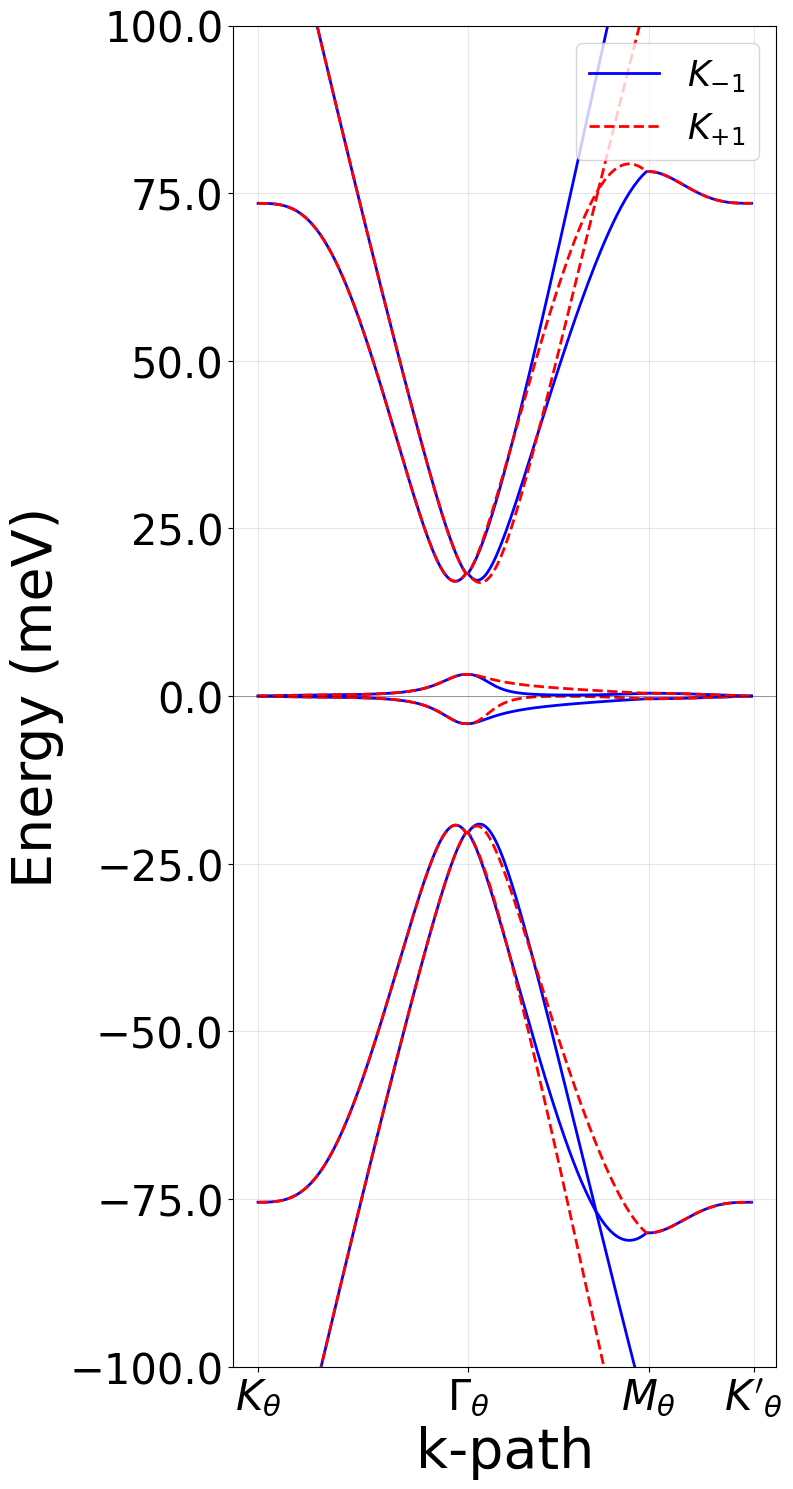

Computing flat bands on 151x151 grid ...
nu = -0.620  ->  fill fraction = 0.1900  ->  mu = -0.416 meV
Fermi contour: 689 total points in central hexagon
Computing Fermi velocity at 689 points ...

Fermi velocity over full Fermi surface:
  min  vF = 8.0577e+03 m/s  (0.005304 eV·nm)
  max  vF = 3.3088e+04 m/s  (0.021779 eV·nm)
  mean vF = 1.9081e+04 m/s  (0.012559 eV·nm)

Fermi crossing points (nm^-1):
  kF+ (phi~0 ): kx = 0.075819,  ky = -0.001550
  kF- (phi~pi): kx = -0.268809,  ky = 0.001550

Fermi velocities:
  v+ (phi~0 ): 0.018505 eV·nm  =  2.8114e+04 m/s
  v- (phi~pi): 0.005326 eV·nm  =  8.0918e+03 m/s

  v+/v- ratio            = 3.474368
  asymmetry (v+-v-)/mean = 110.6019 %

  [Reference: vF monolayer graphene ~ 1.0e6 m/s]


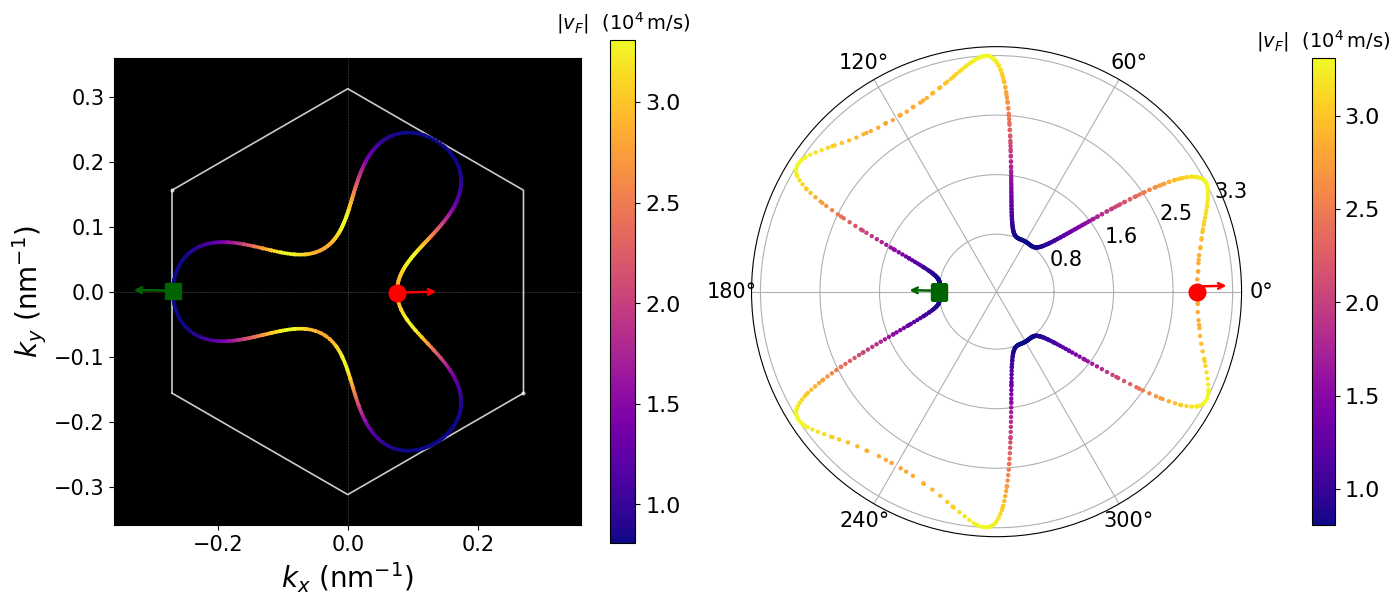

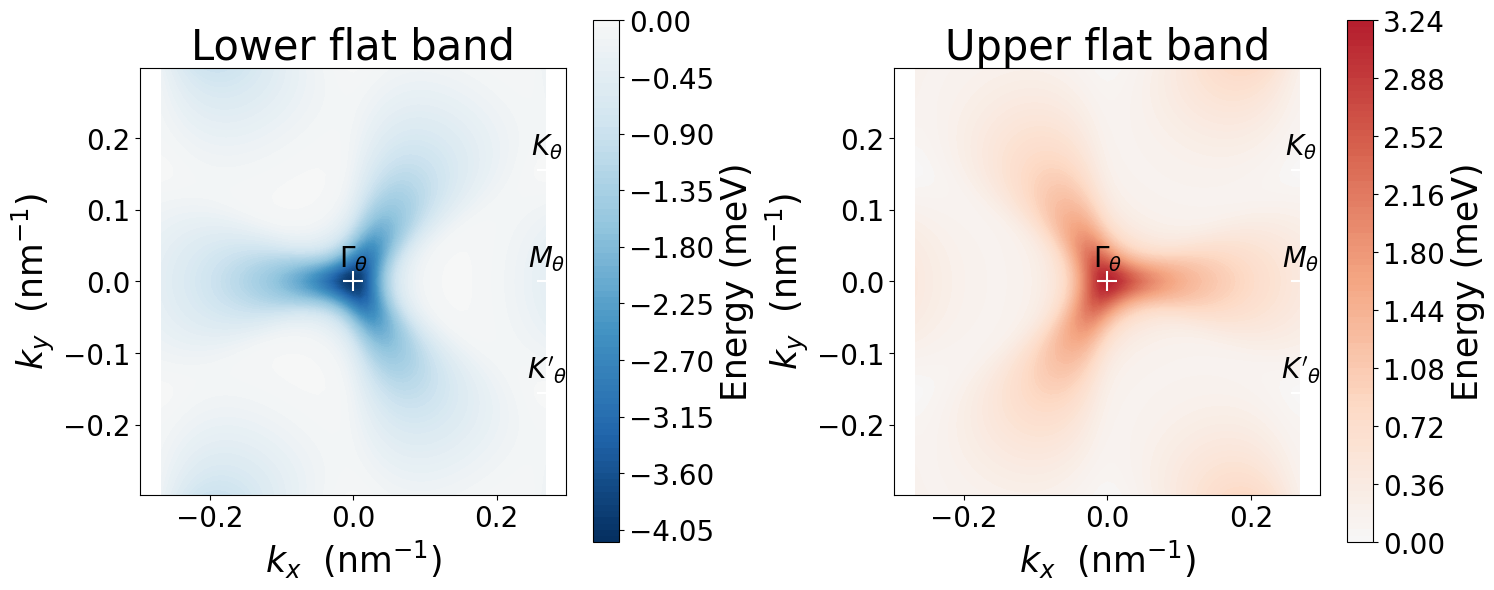

In [47]:

def main():
    # ------------------------------------------------------------------ #
    #  MATBG at the magic angle                                           #
    # ------------------------------------------------------------------ #
    theta_deg = 1.05
    u         = 0.0797
    up        = 0.0975
    vf        = 1.0

    # Band structure K -> Gamma -> M -> K'
    evals_m, evals_p, kpath = solve_band_structure(
        theta_deg, a=0.246, vf=vf, u=u, up=up, cut=4, res=100, plot_it=True)

    # Fermi surface and Fermi velocities
    (v_plus_ms, v_minus_ms, v_plus, v_minus,
     kF_plus, kF_minus,
     fermi_all, all_vF_eVnm, all_vF_ms, all_phi) = compute_fermi_velocities(
        theta_deg, nu=-0.62, a=0.246, vf=vf, u=u, up=up, cut=4,
        nk=151, eta=+1, plot_it=True)

    # Flat band contour plots
    plot_flat_band_contours_MATBG(
        theta_deg=1.05, a=0.246, vf=1.0, u=0.0797, up=0.0975, cut=4,
        nk=61, eta=+1, plot_it=True)

if __name__ == '__main__':
    main()

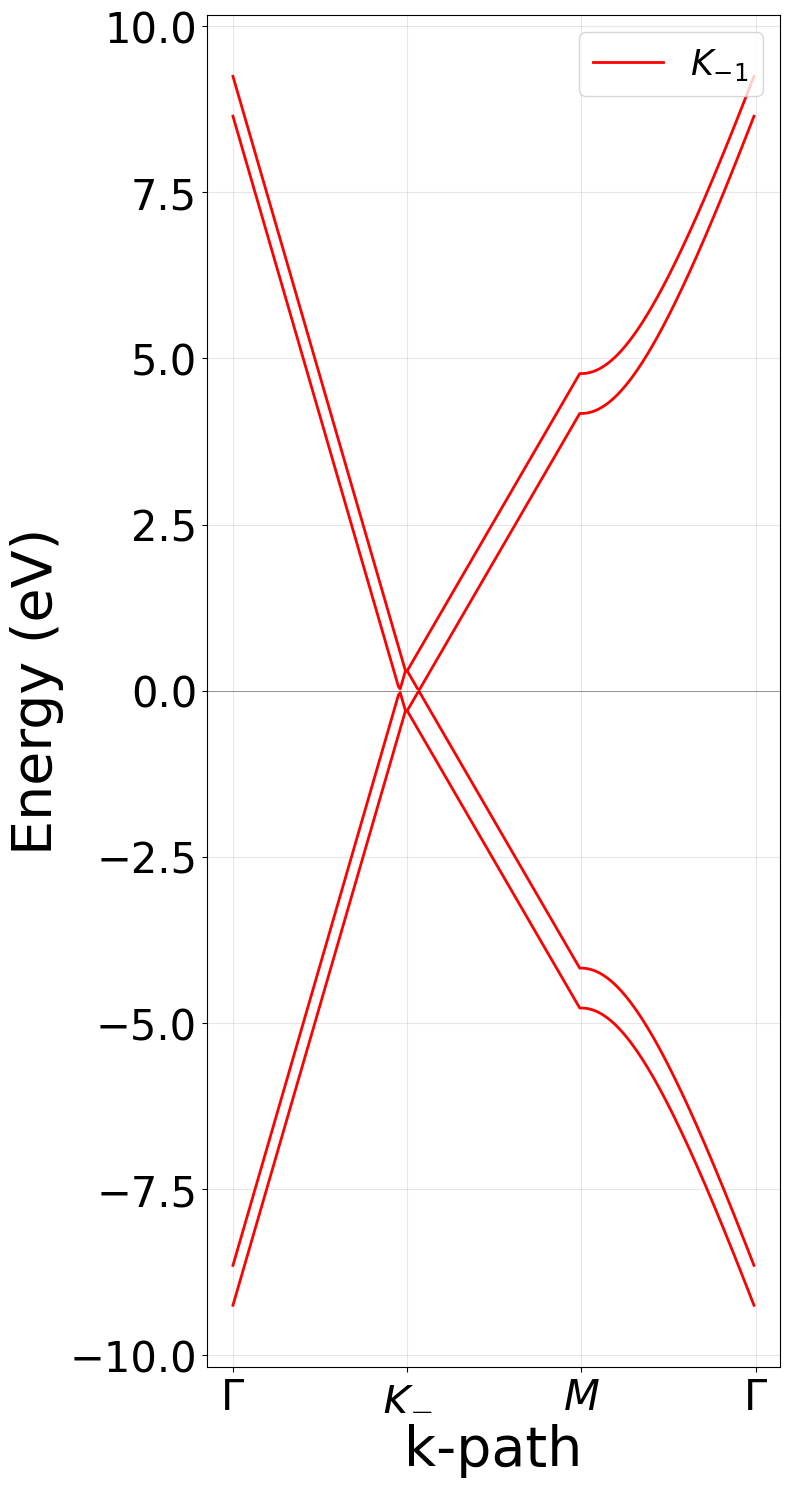

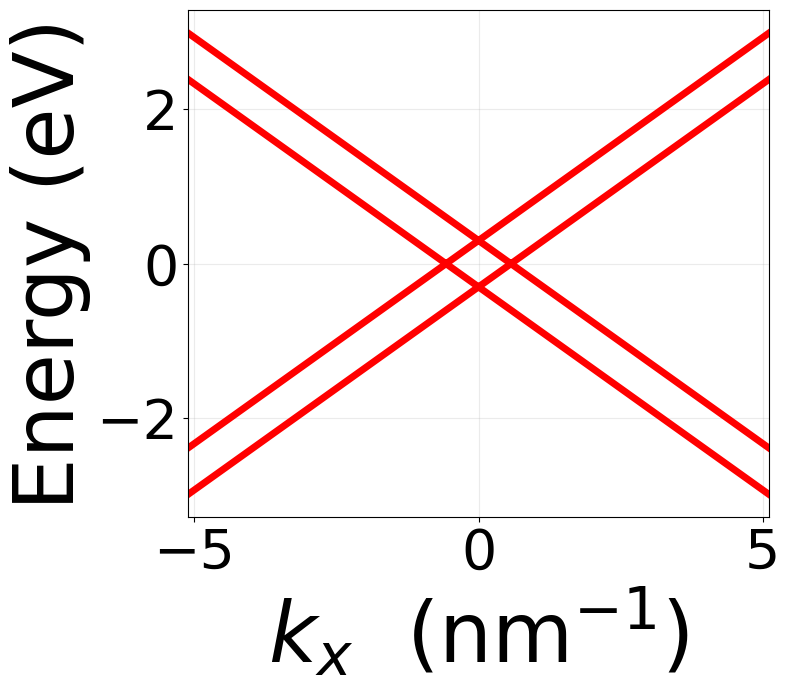

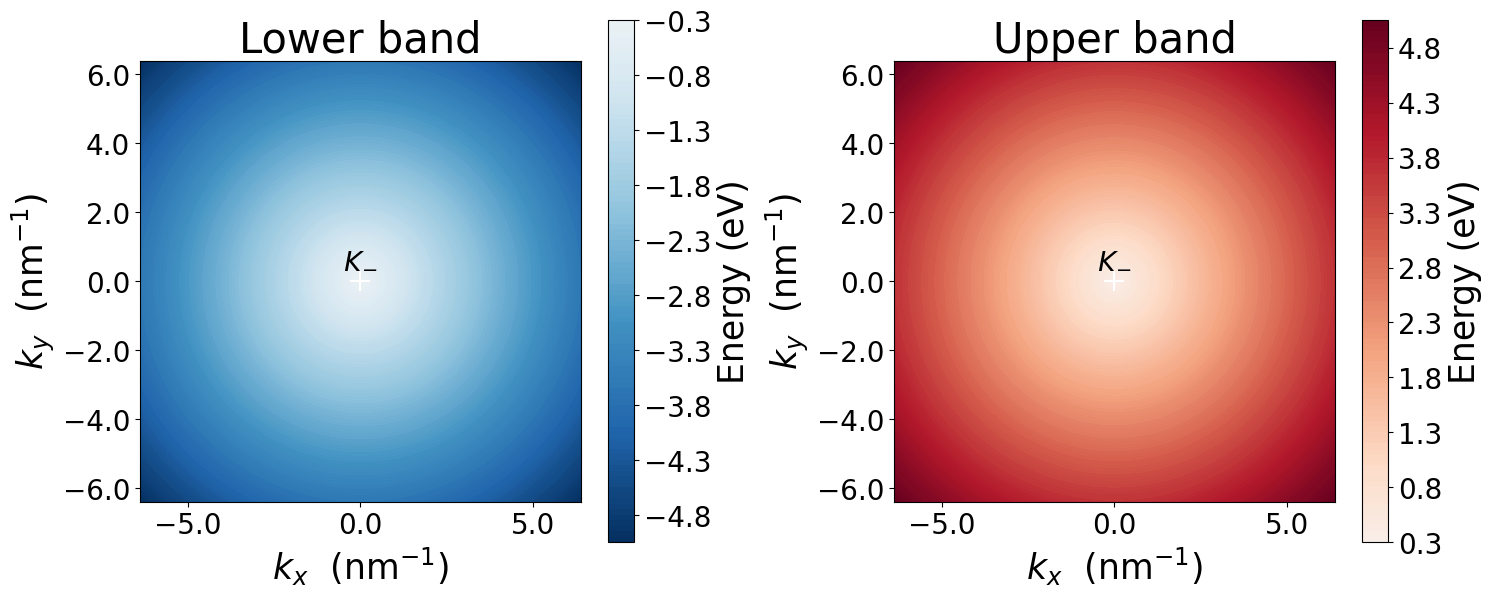

In [46]:
def main():
    # ------------------------------------------------------------------ #
    #  AA-BLG                                                             #
    # ------------------------------------------------------------------ #
    theta_deg = 0
    u         = 0.0797
    up        = 0.0975
    vf        = 1.0



    theta_deg = 0

    # Band structure Gamma -> K -> M -> Gamma
    evals_m, kpath = solve_band_structure(
        theta_deg, a=0.246, vf=vf, u=u, up=up, cut=4, res=100, plot_it=True)

    # Dispersion along ky=0 centred on K
    dkx_arr, evals_p_ky0, evals_m_ky0 = solve_along_ky0(
        theta_deg, a=0.246, vf=vf, u=u, up=up, cut=4, res=500, plot_it=True)

    # Flat band contour plots
    plot_flat_band_contours_AABLG(
        a=0.246, vf=1.0, t_perp=0.3, nk=61, eta=+1, plot_it=True)


if __name__ == '__main__':
    main()